<>:26: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:26: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/hg/6k2xrn0x1hxd4zlz_g32w19h0000gn/T/ipykernel_7734/422197125.py:26: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  s.str.count("\.").values     # number of periods


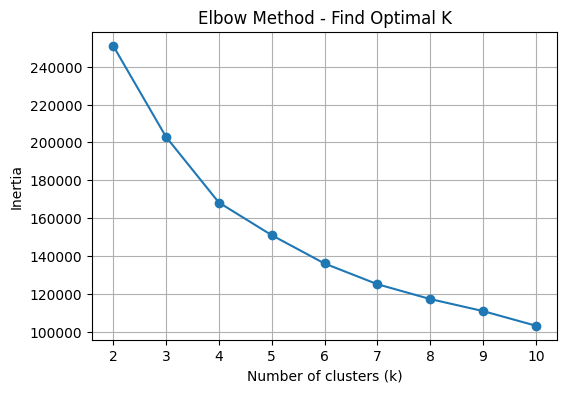

In [1]:
# --- Simple K-Means Clustering based on your dataset ---
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1️⃣ Load your data
df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

text_col = "catalog_content"

df[text_col] = df[text_col].fillna("").astype(str)
test_df[text_col] = test_df[text_col].fillna("").astype(str)

# 2️⃣ Extract simple numeric features
def make_features(s):
    s = s.fillna("").astype(str)
    return np.vstack([
        s.str.len().values,          # text length
        s.str.split().map(len).values,  # word count
        s.str.count(r"\d").values,   # number of digits
        s.str.count(",").values,     # number of commas
        s.str.count("\.").values     # number of periods
    ]).T

X_train_features = make_features(df[text_col])
X_test_features = make_features(test_df[text_col])

# Include sample_id as a numeric feature
X_train_features = np.hstack([X_train_features, df["sample_id"].values.reshape(-1, 1)])
X_test_features = np.hstack([X_test_features, test_df["sample_id"].values.reshape(-1, 1)])

# 3️⃣ Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

# 4️⃣ Use Elbow method (optional) to find best K
inertias = []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker='o')
plt.title("Elbow Method - Find Optimal K")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


In [2]:
# 5️⃣ Train final KMeans model with chosen K (example: k=4)
BEST_K = 4  # 🔧 change based on elbow plot
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_train_scaled)
test_df["cluster"] = kmeans.predict(X_test_scaled)

print("✅ KMeans trained with", BEST_K, "clusters.")
df.head()


✅ KMeans trained with 4 clusters.


,sample_id,catalog_content,image_link,price,cluster
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,3
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,0
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,0
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,2
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,0


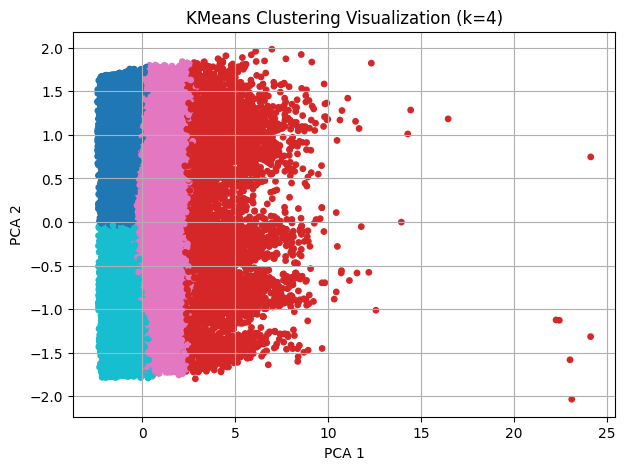

In [3]:
# 6️⃣ Reduce to 2D using PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=df["cluster"], cmap="tab10", s=15)
plt.title(f"KMeans Clustering Visualization (k={BEST_K})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()


In [4]:
# 7️⃣ Save clustered outputs
df.to_csv("train_clusters.csv", index=False)
test_df.to_csv("test_clusters.csv", index=False)
print("💾 Saved cluster-labeled data to 'train_clusters.csv' and 'test_clusters.csv'")


💾 Saved cluster-labeled data to 'train_clusters.csv' and 'test_clusters.csv'
